# CA1 – Categorical Features
Cillian Murphy - X00226829

# 1. Loading Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
bankData = pd.read_csv("bank-additional-full.csv", sep=";")

print(bankData.shape)
bankData.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# 2. Exploratory Data Analysis

In [ ]:
# Separating into only string (obj) features

str_features = bankData.drop(columns="y").select_dtypes(include="object").columns.tolist() # selects all features to a list (excluding y)
bankData[str_features].head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent


Job, contact, month, day_of_week and poutcome are all nominal features as, for example a persons job type has no inherent hierarchy; maritcal, default, housing and loan are also nominal but are binary features (yes or no).

Education is a ordinal feature as education level does have a hierarchy.

## 2.1 Summary Statistics

In [ ]:
bankData[str_features].describe()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563


All features have 41,188 values so there are no empty values however there still could be other versions of missing values such as "unknown", "N/A" etc which is confirmed since default, housing and loan (which are all yes or no values) have 3 unique values. There are 12 different jobs listed in this dataset.
The modes are also displayed here in the "top" row, the mode of poutcome  is "nonexistent" which is a missing value.

## 2.2 Count Histrograms
Histograms for the count and percentage of each categorical feature



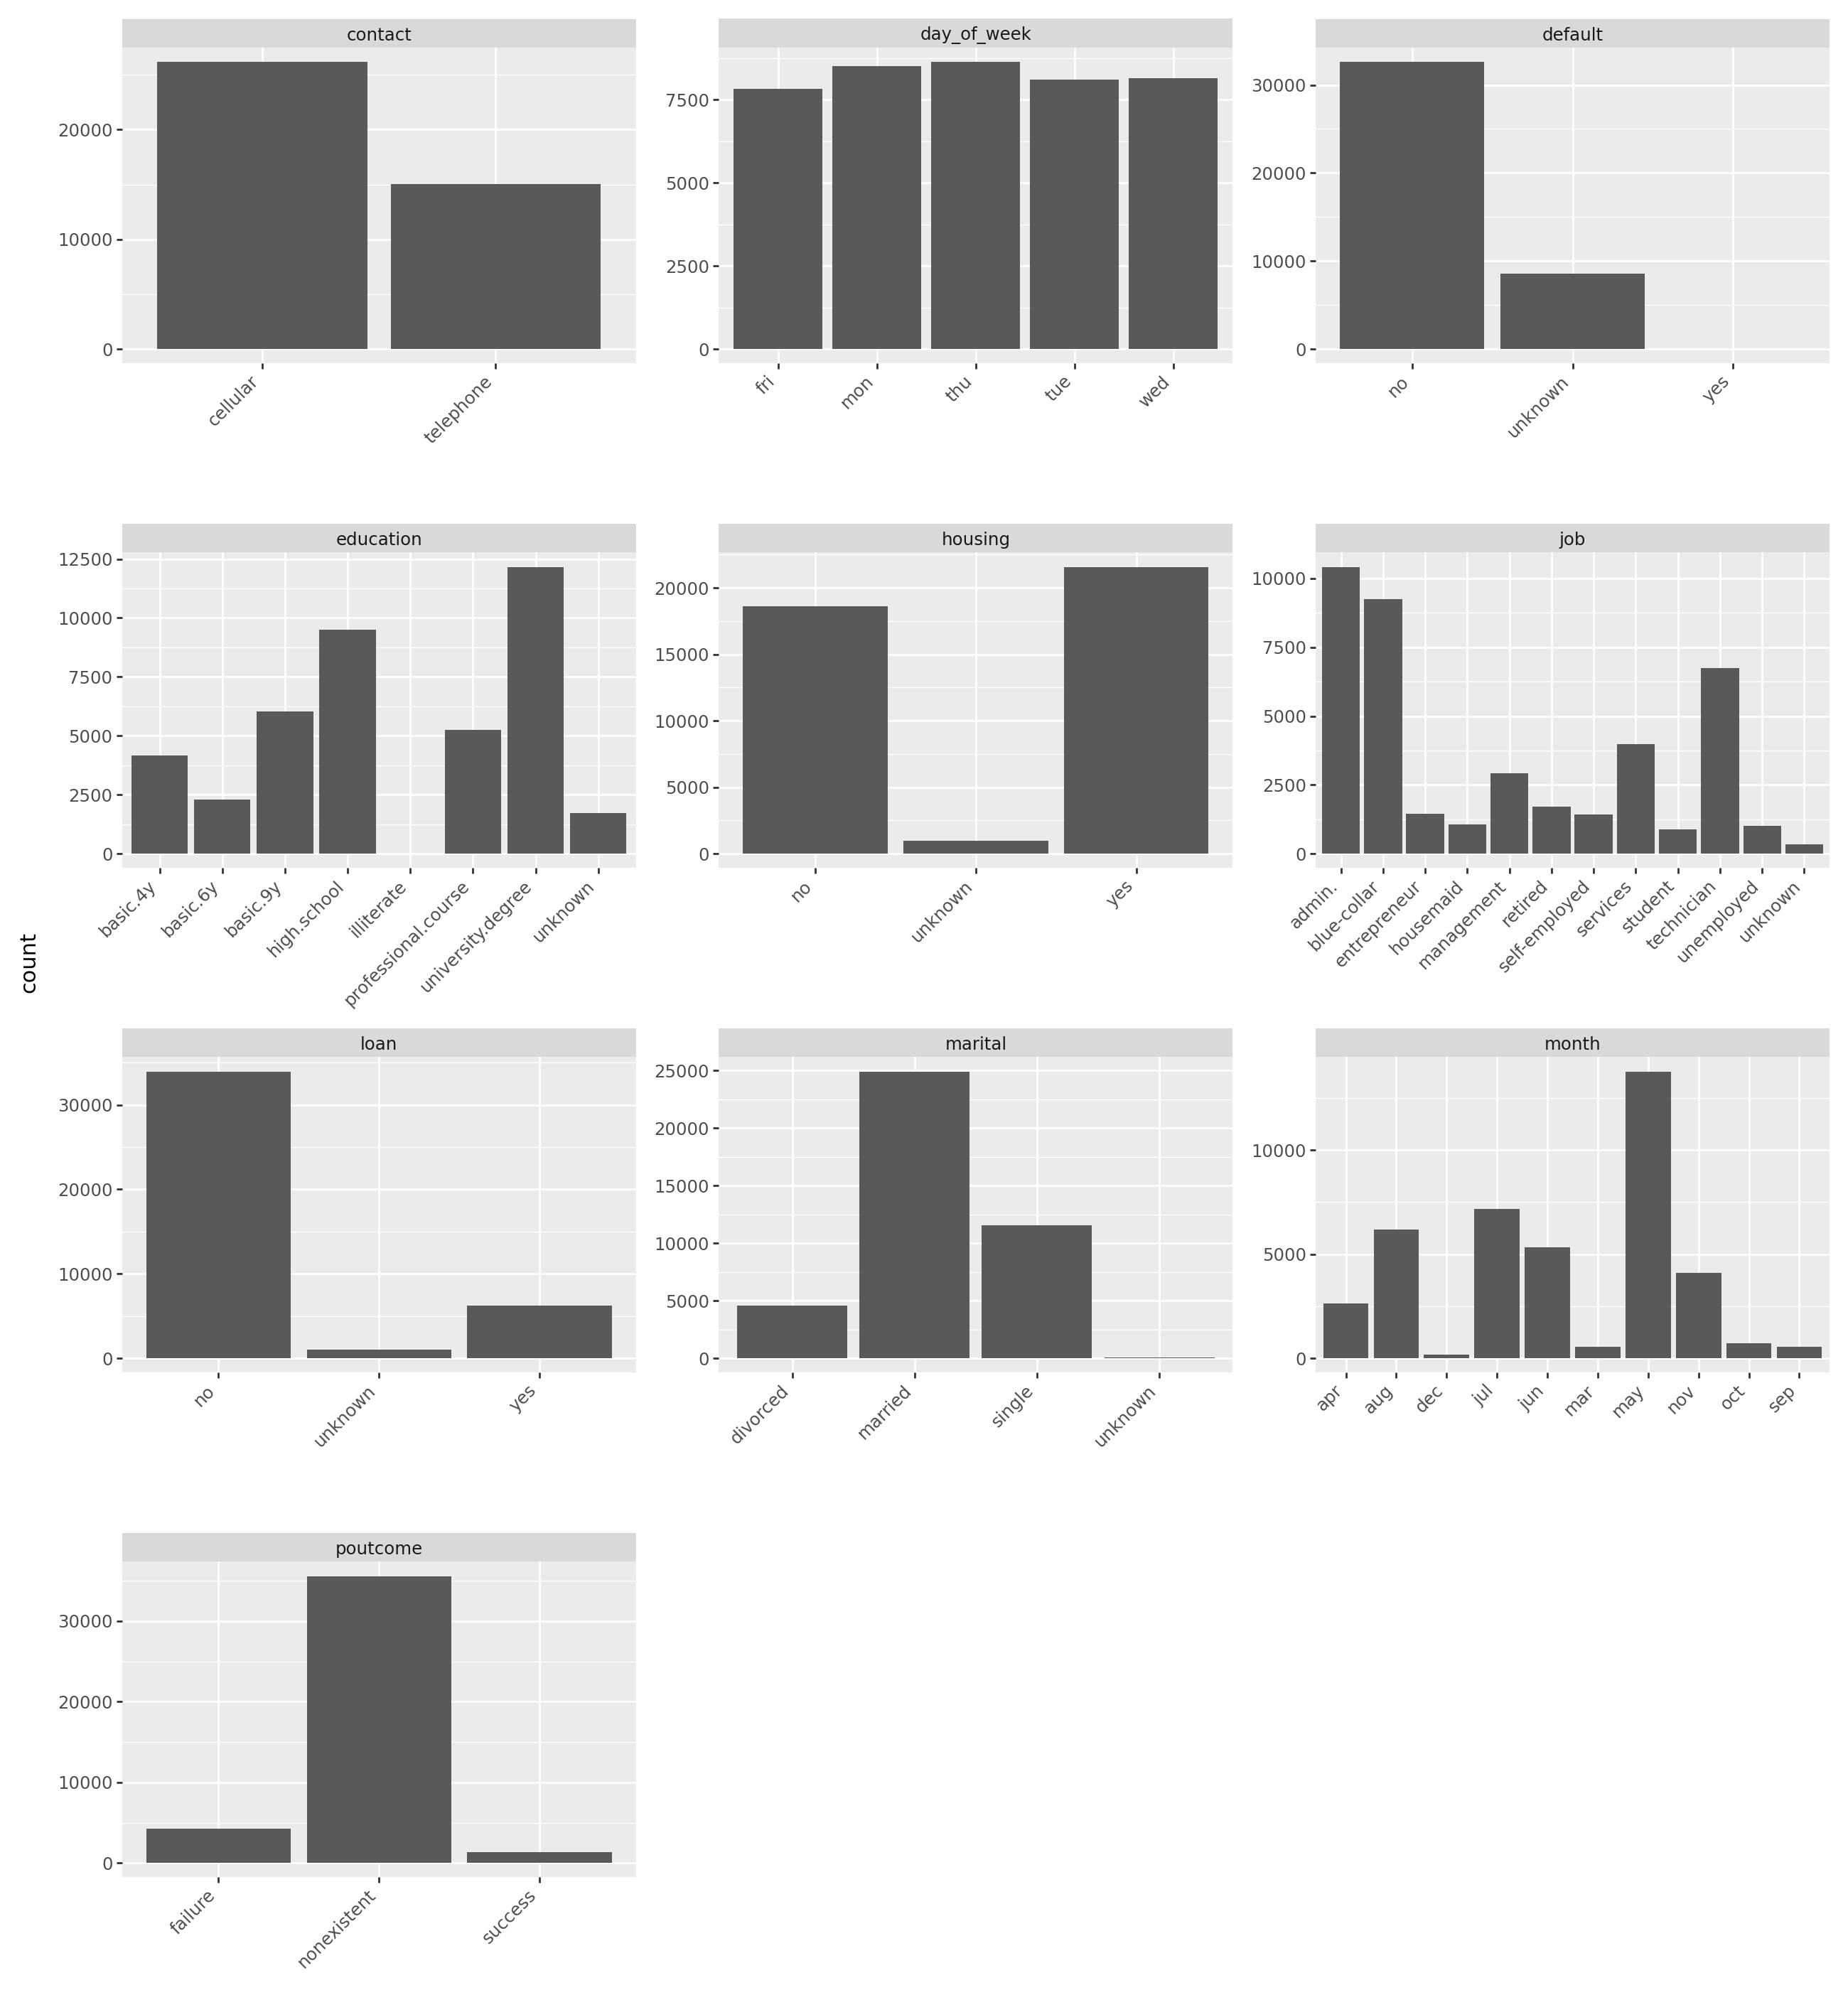

In [ ]:
#combines all features into 2 cols into feature and its value, basically compresses the dataset into 2 columns of the features and their vals
meltedData = bankData[str_features].melt(var_name="feature", value_name="val")

countplot = (
    ggplot(meltedData, aes(x="val"))
    + geom_bar()
    + facet_wrap("feature", ncol=3, scales="free") # splits plit into one panel per feature, free means each feature has its own count range
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(13,14),
        axis_title_x=element_blank() # removes "val" title
    )
)
countplot


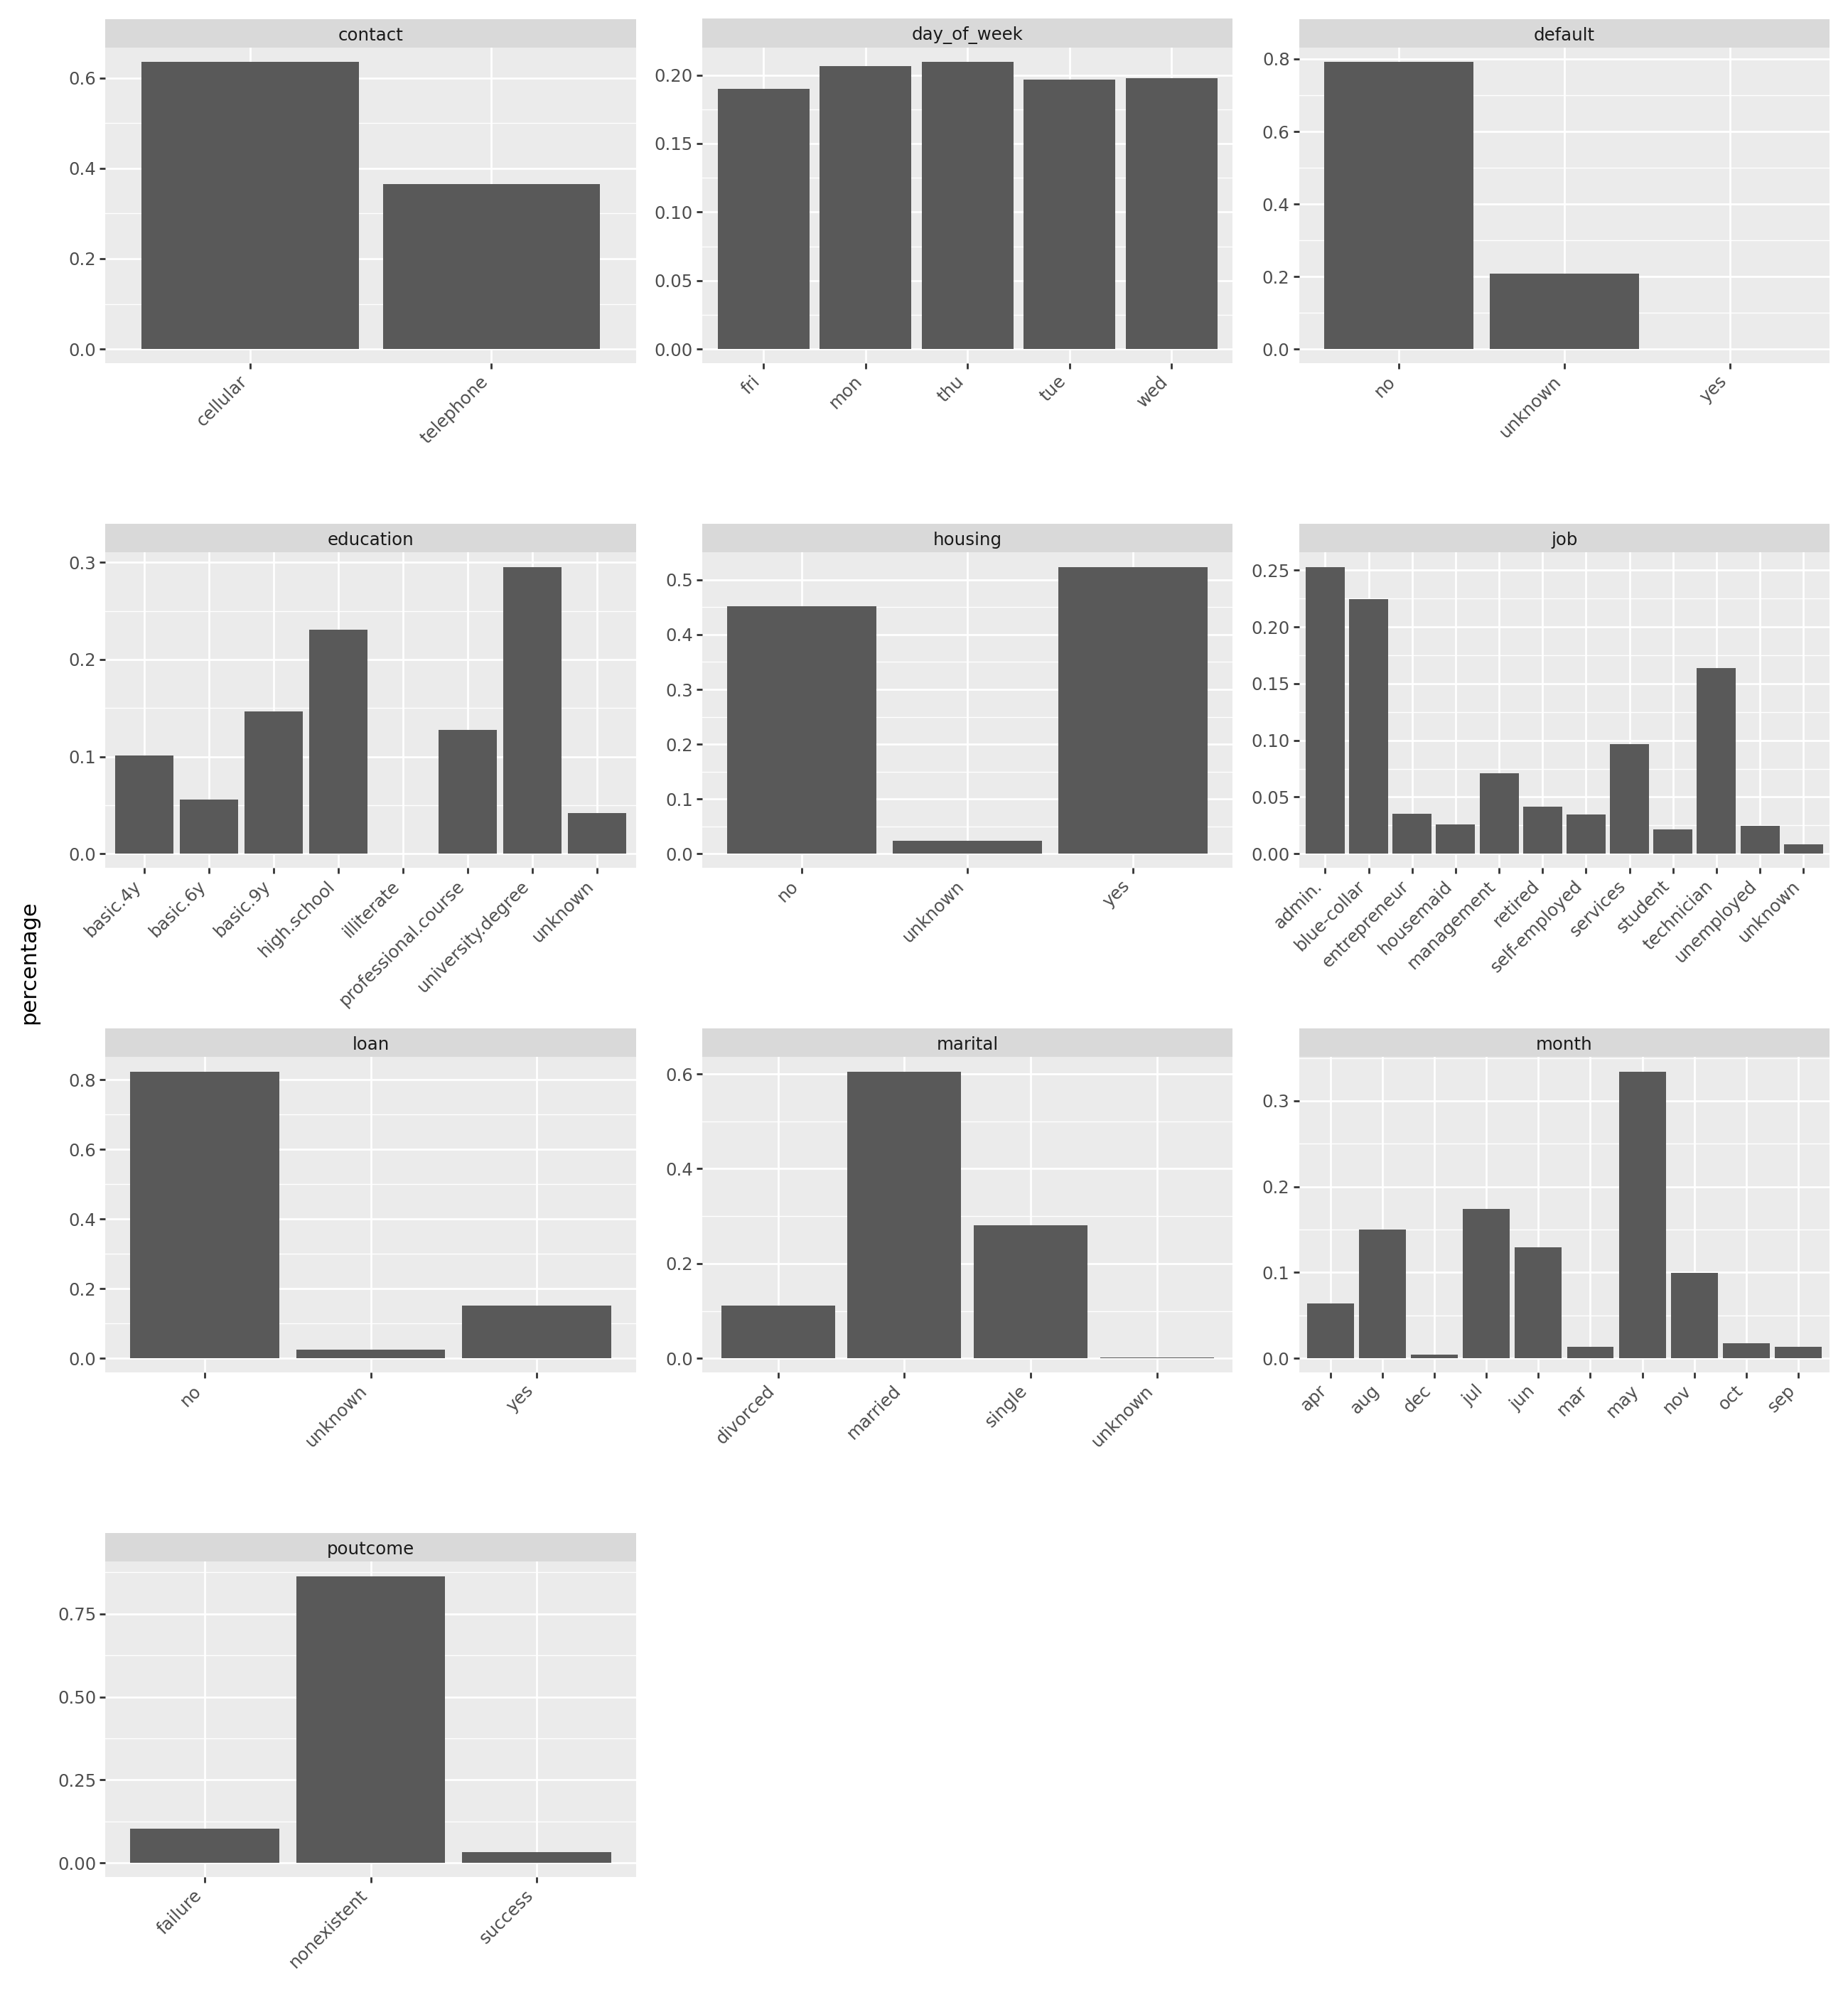

In [ ]:
 # separates each feature into seperate tables of feature and val and gets the percentage rename to set name and reset index to make it a regular df (without an index)
percentage = (
    meltedData.groupby("feature")["val"].value_counts(normalize=True).rename("percentage").reset_index()
)

countplot = (
    ggplot(percentage, aes(x="val", y="percentage"))
    + facet_wrap("feature", ncol=3, scales="free") # splits plit into one panel per feature, free means each feature has its own count range
    + geom_col() # use data supplied in percentage
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(13,14),
        axis_title_x=element_blank() # removes title
    )
)
countplot

using the previous graphs to determine how many unknown values there are

In [ ]:
unknown = ((bankData[str_features] =="unknown").sum()) + ((bankData[str_features] =="nonexistent").sum())
print(unknown)


job              330
marital           80
education       1731
default         8597
housing          990
loan             990
contact            0
month              0
day_of_week        0
poutcome       35563
dtype: int64


## 2.3 Target Balance

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Target Percentage')

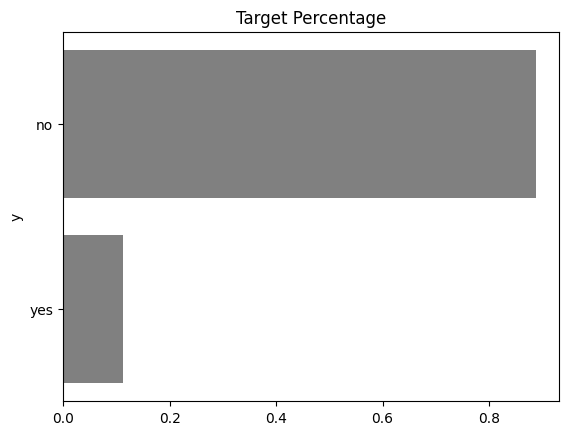

In [ ]:
targetPercentage = bankData["y"].value_counts(normalize=True) # normalize=true to see the percentage of each class
print(targetPercentage)

ax = sns.barplot(x=targetPercentage.values, y=targetPercentage.index, color="gray")
ax.set_title("Target Percentage")

Targets are imbalanced with around 88.7% no and 11.3% yes

## 2.4 Target Rate Per Feature

In [ ]:
yes = (bankData["y"] == "yes")

rates = pd.concat(
    [
        #for each feature group target by otherfeatures, gets the count using "size" and the mean with yes_rate and lastly assigns each row the feature it corresponds to
        yes.groupby(bankData[col]).agg(count="size", yes_rate="mean").reset_index().rename(columns={col: "val"}).assign(feature=col)
        for col in str_features
    ]
)
rates["yes_rate"] = (rates["yes_rate"] * 100) # x 100 to get percentage
rates[["feature", "val", "count", "yes_rate"]]

,feature,val,count,yes_rate
0,job,admin.,10422,12.972558
1,job,blue-collar,9254,6.894316
2,job,entrepreneur,1456,8.516484
3,job,housemaid,1060,10.000000
4,job,management,2924,11.217510
5,job,retired,1720,25.232558
6,job,self-employed,1421,10.485574
7,job,services,3969,8.138070
8,job,student,875,31.428571
9,job,technician,6743,10.826042
